In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/monkeytyping.csv')
df.head()

,participant_id,date,original_filename,trial_number,reaction_time,correct,correct_position,chosen_position,prompt,sample_name,...,file_path,stimuli_quantity,colored,nut_quantity,juice_quantity,datetime,mean_reaction_time,percent_correct,omission_percent,experiment_duration
0,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,1,1029,0,2th,3th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
1,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,2,579,1,2th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
2,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,3,688,0,3th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
3,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,4,578,0,4th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
4,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,5,848,1,4th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"


In [ ]:
df_symbols = df[df['colored'].isna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['file_3_name'].notna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['chosen_position']!='No decision'].copy(deep=True)
df_symbols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4675 entries, 0 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   participant_id             4675 non-null   object 
 1   date                       4675 non-null   object 
 2   original_filename          4675 non-null   object 
 3   trial_number               4675 non-null   int64  
 4   reaction_time              4675 non-null   object 
 5   correct                    4675 non-null   int64  
 6   correct_position           4675 non-null   object 
 7   chosen_position            4675 non-null   object 
 8   prompt                     0 non-null      float64
 9   sample_name                0 non-null      float64
 10  file_1_name                4675 non-null   object 
 11  file_2_name                4675 non-null   object 
 12  file_3_name                4675 non-null   object 
 13  file_4_name                4675 non-null   object 
 1

In [ ]:
image_filepath_main = '/content/drive/MyDrive/monkeytype/emnist_rare_ESRGAN_improved/'
file_cols_name = ['file_1_name', 'file_2_name', 'file_3_name', 'file_4_name']
file_names_from_csv = []
file_names_real_paths = []
for f in file_cols_name:
  df_symbols[f] = df_symbols[f].astype(str)
  for index, row in df_symbols.iterrows():
    df_symbols.loc[index, f] = df_symbols.loc[index, f][0] + '/'+df_symbols.loc[index, f][2:] + '_out.png'
print(df_symbols[file_cols_name[0]])

0       y/00902_out.png
1       s/00320_out.png
2       c/01270_out.png
3       f/00745_out.png
4       s/01180_out.png
             ...       
6154    f/01252_out.png
6155    m/01187_out.png
6156    m/00439_out.png
6157    m/00413_out.png
6158    c/00117_out.png
Name: file_1_name, Length: 4675, dtype: object


In [ ]:
df_Jupiter = df_symbols[df_symbols['participant_id']=='Jupiter'].copy(deep=True)
df_Jupiter['datetime'] = pd.to_datetime(df_Jupiter['datetime'], format='%d.%m.%Y %H:%M:%S')

In [ ]:
df_Feliks = df_symbols[df_symbols['participant_id']=='Feliks'].copy(deep=True)
df_Feliks['datetime'] = pd.to_datetime(df_Feliks['datetime'], format='%d.%m.%Y %H:%M:%S')

In [ ]:
df_Yunt = df_symbols[df_symbols['participant_id']=='Yunt'].copy(deep=True)
df_Yunt['datetime'] = pd.to_datetime(df_Yunt['datetime'], format='%d.%m.%Y %H:%M:%S')

In [ ]:
df_Yunt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1638 entries, 3618 to 6158
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   participant_id             1638 non-null   object        
 1   date                       1638 non-null   object        
 2   original_filename          1638 non-null   object        
 3   trial_number               1638 non-null   int64         
 4   reaction_time              1638 non-null   object        
 5   correct                    1638 non-null   int64         
 6   correct_position           1638 non-null   object        
 7   chosen_position            1638 non-null   object        
 8   prompt                     0 non-null      float64       
 9   sample_name                0 non-null      float64       
 10  file_1_name                1638 non-null   object        
 11  file_2_name                1638 non-null   object        
 12  file_3_n

In [ ]:
segments = [g for _, g in df_Jupiter.groupby('datetime')[['datetime', 'correct_position', 'chosen_position', 'percent_correct','omission_percent']]]
#print(segments[0])
for s in segments:
  omission = 0.0
  accuracy = 0.0
  iters = 0.0
  iters_omis = 0.0
  for index, row in s.iterrows():
    index_char = s.loc[index, 'chosen_position'][0]
    iters_omis+=1.0
    if index_char!="N":
      iters+=1.0
      if s.loc[index, 'chosen_position'][0]==s.loc[index, 'correct_position'][0]:
        accuracy+=1.0
    else:
      omission+=1.0
  accuracy/=iters
  accuracy*=100
  omission/=iters_omis
  omission*=100
  for index, row in s.iterrows():
    s.loc[index, 'percent_correct'] = accuracy
    #s.loc[index, 'omission_percent'] = omission
print(segments[0])
mean_accuracy = 0.0
for s in segments:
  mean_accuracy+=s['percent_correct'].unique()
mean_accuracy/=len(segments)

print(mean_accuracy)

              datetime correct_position chosen_position  percent_correct  \
0  2025-06-02 11:59:45              2th             3th        35.416667   
1  2025-06-02 11:59:45              2th             2th        35.416667   
2  2025-06-02 11:59:45              3th             4th        35.416667   
3  2025-06-02 11:59:45              4th             2th        35.416667   
4  2025-06-02 11:59:45              4th             4th        35.416667   
5  2025-06-02 11:59:45              1th             1th        35.416667   
6  2025-06-02 11:59:45              1th             1th        35.416667   
7  2025-06-02 11:59:45              2th             4th        35.416667   
8  2025-06-02 11:59:45              1th             3th        35.416667   
9  2025-06-02 11:59:45              4th             3th        35.416667   
10 2025-06-02 11:59:45              1th             3th        35.416667   
11 2025-06-02 11:59:45              3th             2th        35.416667   
12 2025-06-0

In [ ]:
segments_rows=[i.iloc[0] for i in segments]
df_time_and_acc = pd.DataFrame(segments_rows)
df_time_and_acc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 0 to 2108
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          43 non-null     datetime64[ns]
 1   correct_position  43 non-null     object        
 2   chosen_position   43 non-null     object        
 3   percent_correct   43 non-null     float64       
 4   omission_percent  43 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.0+ KB


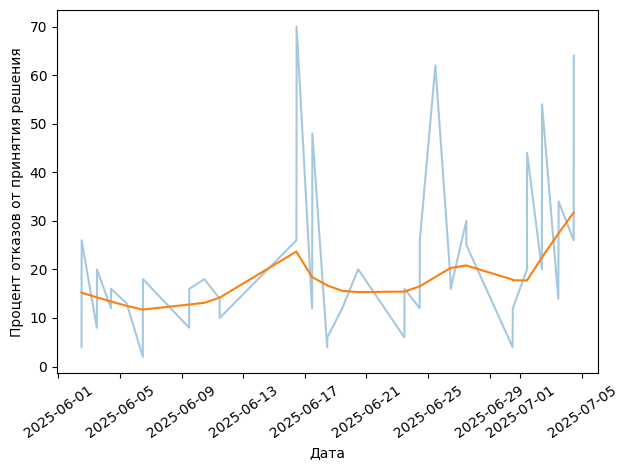

In [ ]:
import statsmodels.api as sm

lowess = sm.nonparametric.lowess
#df_time_and_acc['lowess'] = lowess(df_time_and_acc['percent_correct'], df_time_and_acc['datetime'], frac=0.5)[:,1]
df_time_and_acc['lowess2'] = lowess(df_time_and_acc['omission_percent'], df_time_and_acc['datetime'], frac=0.3)[:,1]
#plt.plot(df_time_and_acc['datetime'], df_time_and_acc['percent_correct'], alpha =0.4)
#plt.plot(df_time_and_acc['datetime'], df_time_and_acc['lowess'])
plt.plot(df_time_and_acc['datetime'],df_time_and_acc['omission_percent'], alpha =0.4) #df_time_and_acc['datetime'],
plt.plot(df_time_and_acc['datetime'],df_time_and_acc['lowess2'], 'tab:orange')
plt.xlabel("Дата")
plt.ylabel("Процент отказов от принятия решения")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [ ]:
hist_df = pd.DataFrame(columns=['datetime','1th', '2th', '3th', '4th']) #'No decision'])
for i in range(len(segments)):
  hist_df.loc[i]=[segments[i].iloc[0,0], 0,0,0,0] #,0]
  smt = segments[i]['chosen_position'].value_counts().reset_index()
  smt.columns = ['string', 'count']
  for index, row in smt.iterrows():
    hist_df.loc[i, smt.loc[index,'string']] = smt.loc[index,'count']
hist_df

,datetime,1th,2th,3th,4th
0,2025-06-02 11:59:45,8,10,21,9
1,2025-06-02 12:10:42,11,11,13,2
2,2025-06-03 11:51:28,10,13,14,9
3,2025-06-03 12:05:15,6,12,20,2
4,2025-06-04 09:52:14,12,17,12,3
5,2025-06-04 10:01:52,5,18,18,1
6,2025-06-05 10:29:37,5,26,14,1
7,2025-06-06 11:33:27,9,18,18,4
8,2025-06-06 11:44:17,11,25,5,0
9,2025-06-09 11:44:50,6,26,13,1


In [ ]:
probs1 = hist_df[['1th', '2th', '3th', '4th']]
probs = probs1.div(probs1.sum(axis=1), axis=0)
hist_df['entropy'] = -(probs.where(probs > 0) * np.log2(probs.where(probs > 0))).sum(axis=1)/2
hist_df

,datetime,1th,2th,3th,4th,entropy
0,2025-06-02 11:59:45,8,10,21,9,0.938447
1,2025-06-02 12:10:42,11,11,13,2,0.899143
2,2025-06-03 11:51:28,10,13,14,9,0.988332
3,2025-06-03 12:05:15,6,12,20,2,0.823865
4,2025-06-04 09:52:14,12,17,12,3,0.908342
5,2025-06-04 10:01:52,5,18,18,1,0.770838
6,2025-06-05 10:29:37,5,26,14,1,0.727824
7,2025-06-06 11:33:27,9,18,18,4,0.902798
8,2025-06-06 11:44:17,11,25,5,0,0.657315
9,2025-06-09 11:44:50,6,26,13,1,0.741923


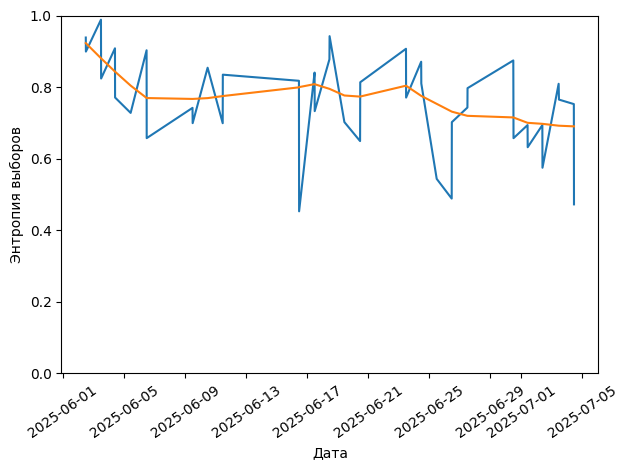

In [ ]:
lowess = sm.nonparametric.lowess
hist_df['lowess'] = lowess(hist_df['entropy'], df_time_and_acc['datetime'], frac=0.3)[:,1]
plt.plot(hist_df['datetime'],hist_df['entropy'])
plt.plot(hist_df['datetime'],hist_df['lowess'])
plt.xlabel("Дата")
plt.ylabel("Энтропия выборов")
plt.ylim(0,1)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
hist_df = hist_df[['1th', '2th', '3th', '4th']]
sns.heatmap(hist_df, annot=False)  # annot=True, если хочешь числа внутри
plt.xlabel("X (keys)")
plt.ylabel("Y (sessions)")
plt.title("Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
symbols_cols = ['m', 'c', 's', 'y', 'f', 'j']
n_rows = 1
df_sym_hist = pd.DataFrame(np.zeros((n_rows, len(symbols_cols))),columns=symbols_cols)
for index, row in df_Yunt.iterrows():
  f = ''
  index_ch = df_Yunt.loc[index, 'chosen_position'][0]
  if index_ch!="N":
    for i, s in enumerate(file_cols_name):
      if index_ch in s:
        f = file_cols_name[i]
    symbol2count = df_Yunt.loc[index, f][0]
    df_sym_hist.loc[0, symbol2count]+=1.0

values = df_sym_hist.iloc[0]
fig, ax = plt.subplots()
ax.bar(values.index, values.values, label=values.values)

plt.show()
